# Day 31: Student Performance & Learning Analytics

**Dataset:** `Student_Performance_Dataset.csv`

This notebook is the first of three days in the Student Performance & Learning Analytics
project. It prepares the student dataset, builds a data cleaning pipeline, explores the
cleaned data, and analyzes attendance.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../datasets/Student_Performance_Dataset.csv")

# Preview the data
df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [2]:
print(df.shape)
df.info()

(10000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   str    
 1   gender                       9982 non-null   str    
 2   race_ethnicity               9977 non-null   str    
 3   parental_level_of_education  9978 non-null   str    
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   str    
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   str    
dtypes: float64(6), str(6)
memory usage: 937.6 KB


## 2. Student Dataset Overview

**Missing-value summary: count and percentage missing in every column**

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})
missing_summary

,missing_count,missing_percent
roll_no,1,0.01
gender,18,0.18
race_ethnicity,23,0.23
parental_level_of_education,22,0.22
lunch,24,0.24
test_preparation_course,23,0.23
math_score,24,0.24
reading_score,25,0.25
writing_score,24,0.24
science_score,23,0.23


In [4]:
print("Rows with at least one missing value:", df.isna().any(axis=1).sum())
print("Total duplicate rows:", df.duplicated().sum())

Rows with at least one missing value: 213
Total duplicate rows: 0


**Checking the category columns for inconsistent labels**

In [5]:
for col in ["gender", "race_ethnicity"]:
    print(df[col].value_counts(dropna=False))
    print()

gender
female    4983
male      4982
NaN         18
Girl        10
Boy          6
\tmale       1
Name: count, dtype: int64

race_ethnicity
group C      2921
group D      2566
group B      1899
group E      1509
group A      1062
NaN            23
D               6
group C\n       4
E               4
C               3
A               2
B               1
Name: count, dtype: int64



**`math_score` should be numeric, but it was loaded as text**

In [6]:
print("math_score dtype:", df["math_score"].dtype)

bad_math = pd.to_numeric(df["math_score"], errors="coerce").isna() & df["math_score"].notna()
df.loc[bad_math, ["roll_no", "math_score"]]

math_score dtype: str


,roll_no,math_score
2865,std-2866,\t41


**Observation:** the dataset is intentionally messy. 213 of the 10,000 rows have at least
one missing value, spread thinly across nearly every column (roughly 20 per column, or about
0.2% each). The category columns are inconsistent too: `gender` mixes `male` and `female`
with `Boy`, `Girl`, and a stray `\tmale`, while `race_ethnicity` mixes `group C` with bare
letters like `D` and a stray `group C\n`. `math_score` is stored as text only because of one
entry, `\t41`, which contains a literal tab escape. There are no duplicate rows, but the
dataset also has **no attendance or study-time column**, even though both are central to
this project. Section 4 deals with that.

## 3. Data Cleaning Pipeline

The cleaning is built as a **pipeline of three small functions**, each fixing one kind of
problem, and chained together with `.pipe()` so the raw `df` is never modified.

In [7]:
SCORE_COLS = ["math_score", "reading_score", "writing_score", "science_score"]
GRADE_BINS = [0, 150, 200, 250, 320, 401]
GRADE_LABELS = ["Fail", "D", "C", "B", "A"]

# Records what each step changed, so the results can be summarized later
cleaning_log = {}

**Step 1: standardize the text labels and fix the `math_score` type**

The stray `\t` and `\n` escapes are removed first, `Boy` and `Girl` are mapped to `male` and
`female`, and single letters in `race_ethnicity` are expanded to the full `group X` label.

In [8]:
def fix_text_labels(data):
    data = data.copy()

    text_cols = ["roll_no", "gender", "race_ethnicity", "parental_level_of_education", "grade", "math_score"]
    for col in text_cols:
        data[col] = data[col].astype("string").str.replace(r"\\[tn]", "", regex=True).str.strip()

    data["gender"] = data["gender"].replace({"Boy": "male", "Girl": "female"})
    data["race_ethnicity"] = data["race_ethnicity"].str.replace(r"^([A-E])$", r"group \1", regex=True)
    data["math_score"] = pd.to_numeric(data["math_score"]).astype("float64")

    print("Step 1 done: text labels standardized and math_score converted to numeric")
    return data

**Step 2: recover missing values that the data itself can tell us**

Not every missing value needs to be guessed. `roll_no` follows a fixed pattern by row
position (`std-01`, `std-02`, and so on). `total_score` is always the sum of the four
subject scores, so a single missing subject score can be rebuilt as `total_score` minus the
other three, and a missing `total_score` can be recomputed from the scores. The grades
follow score bands, so a missing `grade` can be filled from `total_score` once the rule is
confirmed against the grades that already exist.

In [9]:
def recover_missing_values(data):
    data = data.copy()

    # 1. roll_no follows the pattern std-01, std-02, ... by row position
    missing_roll = data["roll_no"].isna()
    data.loc[missing_roll, "roll_no"] = [f"std-{i + 1:02d}" for i in data.index[missing_roll]]
    cleaning_log["recovered_roll_no"] = int(missing_roll.sum())

    # 2. A single missing subject score can be rebuilt from total_score
    n_missing = data[SCORE_COLS].isna().sum(axis=1)
    recoverable = (n_missing == 1) & data["total_score"].notna()
    recovered_scores = 0
    for col in SCORE_COLS:
        others = [c for c in SCORE_COLS if c != col]
        rows = recoverable & data[col].isna()
        data.loc[rows, col] = data.loc[rows, "total_score"] - data.loc[rows, others].sum(axis=1)
        recovered_scores += int(rows.sum())
    cleaning_log["recovered_scores"] = recovered_scores

    # 3. A missing total_score can be recomputed when all four scores are present
    rows = data["total_score"].isna() & data[SCORE_COLS].notna().all(axis=1)
    data.loc[rows, "total_score"] = data.loc[rows, SCORE_COLS].sum(axis=1)
    cleaning_log["recovered_totals"] = int(rows.sum())

    # 4. A missing grade can be filled from the score band, after checking the rule
    rule = pd.cut(data["total_score"], bins=GRADE_BINS, labels=GRADE_LABELS, right=False).astype("string")
    both = data["grade"].notna() & rule.notna()
    cleaning_log["grade_rule_matches"] = int((rule[both] == data.loc[both, "grade"]).sum())
    cleaning_log["grade_rule_checked"] = int(both.sum())
    rows = data["grade"].isna() & rule.notna()
    data.loc[rows, "grade"] = rule[rows]
    cleaning_log["recovered_grades"] = int(rows.sum())

    print("Step 2 done:")
    print("  roll_no recovered:", cleaning_log["recovered_roll_no"])
    print("  subject scores recovered from total_score:", cleaning_log["recovered_scores"])
    print("  total_score recomputed from the four scores:", cleaning_log["recovered_totals"])
    print("  grades filled from score bands:", cleaning_log["recovered_grades"])
    print(f"  grade rule matched {cleaning_log['grade_rule_matches']} of {cleaning_log['grade_rule_checked']} existing grades")
    return data

**Step 3: handle what is left**

If a row is still missing a score after Step 2, its score cannot be rebuilt without
guessing, so those rows are dropped (a very small number). The remaining gaps are all in
category or 0/1 columns, each missing only about 20 values, so they are filled with the most
frequent value (the mode). Finally, the score and 0/1 columns are converted back to
integers.

In [10]:
def handle_remaining_missing(data):
    data = data.copy()

    before = len(data)
    data = data.dropna(subset=SCORE_COLS + ["total_score"])
    cleaning_log["dropped_rows"] = before - len(data)

    fill_cols = ["gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course"]
    cleaning_log["filled_with_mode"] = int(data[fill_cols].isna().sum().sum())
    for col in fill_cols:
        data[col] = data[col].fillna(data[col].mode()[0])

    for col in SCORE_COLS + ["total_score", "lunch", "test_preparation_course"]:
        data[col] = data[col].astype(int)

    print("Step 3 done:")
    print("  rows dropped (scores could not be recovered):", cleaning_log["dropped_rows"])
    print("  category and 0/1 values filled with the mode:", cleaning_log["filled_with_mode"])
    return data.reset_index(drop=True)

**Running the full pipeline on the raw data**

In [11]:
df_clean = (
    df.pipe(fix_text_labels)
    .pipe(recover_missing_values)
    .pipe(handle_remaining_missing)
)

print()
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)
print("Missing values left:", df_clean.isna().sum().sum())

Step 1 done: text labels standardized and math_score converted to numeric
Step 2 done:
  roll_no recovered: 1
  subject scores recovered from total_score: 80
  total_score recomputed from the four scores: 16
  grades filled from score bands: 3
  grade rule matched 9994 of 9994 existing grades
Step 3 done:
  rows dropped (scores could not be recovered): 9
  category and 0/1 values filled with the mode: 110

Shape before cleaning: (10000, 12)
Shape after cleaning: (9991, 12)
Missing values left: 0


**Validation checks on the cleaned data: how many rows fail each check (every value should be 0)**

In [12]:
expected_grade = pd.cut(df_clean["total_score"], bins=GRADE_BINS, labels=GRADE_LABELS, right=False).astype(str)

validation = pd.Series({
    "Subject scores within 0-100": ((df_clean[SCORE_COLS] < 0) | (df_clean[SCORE_COLS] > 100)).any(axis=1).sum(),
    "total_score equals the sum of the four scores": (df_clean[SCORE_COLS].sum(axis=1) != df_clean["total_score"]).sum(),
    "grade matches the total_score band": (expected_grade != df_clean["grade"].astype(str)).sum(),
    "gender is male or female": (~df_clean["gender"].isin(["male", "female"])).sum(),
    "race_ethnicity is group A to group E": (~df_clean["race_ethnicity"].isin([f"group {x}" for x in "ABCDE"])).sum(),
    "roll_no is unique": df_clean["roll_no"].duplicated().sum(),
    "lunch and test_preparation_course are 0 or 1": (~df_clean[["lunch", "test_preparation_course"]].isin([0, 1]).all(axis=1)).sum(),
    "No missing values left": df_clean.isna().sum().sum(),
}, name="rows_failing")

validation.to_frame()

,rows_failing
Subject scores within 0-100,0
total_score equals the sum of the four scores,0
grade matches the total_score band,0
gender is male or female,0
race_ethnicity is group A to group E,0
roll_no is unique,0
lunch and test_preparation_course are 0 or 1,0
No missing values left,0


**Observation:** the pipeline recovered 80 missing subject scores, 16 totals, 3 grades, and
1 roll number instead of discarding those rows, and the grade rule reproduced all 9,994
grades that were already present, which is what makes it safe to use for the rest. Only 9
rows (0.09% of the data) had to be dropped, leaving 9,991 students. All eight validation
checks come back with 0 failing rows. One thing worth noting: 33 students have a
`math_score` of exactly 0. That is a valid value inside the 0-100 range, so those rows were
kept.

## 4. Adding Attendance and Study Time

The real dataset has no attendance or study-time column, but the project needs both. The
task allows a public or synthetic dataset, so I added two **simulated** columns, clearly
separated from the real data and generated with a fixed random seed so the results are
reproducible:

- `attendance_percentage`: centered around 80%, nudged up or down by how far a student's average score is from the class average, plus random noise
- `study_hours_per_week`: centered around 6 hours, with extra hours for students who took the test preparation course, a small nudge from average score, plus random noise

Because these columns were built with a link to performance, any relationship found later is
**by construction**, not a real-world finding. The goal here is to practice the analysis
workflow.

In [13]:
rng = np.random.default_rng(42)

df_clean["average_score"] = (df_clean["total_score"] / 4).round(2)
z_score = (df_clean["average_score"] - df_clean["average_score"].mean()) / df_clean["average_score"].std()

df_clean["attendance_percentage"] = np.clip(rng.normal(80 + 3.5 * z_score, 9), 40, 100).round(1)
df_clean["study_hours_per_week"] = np.clip(
    rng.normal(6 + 2.5 * df_clean["test_preparation_course"] + 1.0 * z_score, 2.5), 0, 20
).round(1)

df_clean[["roll_no", "average_score", "attendance_percentage", "study_hours_per_week"]].head()

,roll_no,average_score,attendance_percentage,study_hours_per_week
0,std-01,59.50,80.5,3.3
1,std-02,82.00,75.9,6.2
2,std-03,66.00,86.7,7.7
3,std-04,49.50,82.9,5.4
4,std-05,53.25,58.2,11.3


## 5. Exploratory Data Analysis

**Summary statistics for the numeric columns**

In [14]:
numeric_cols = SCORE_COLS + ["total_score", "average_score", "attendance_percentage", "study_hours_per_week"]
df_clean[numeric_cols].describe().round(2)

,math_score,reading_score,writing_score,science_score,total_score,average_score,attendance_percentage,study_hours_per_week
count,9991.00,9991.00,9991.00,9991.00,9991.00,9991.00,9991.00,9991.00
mean,57.16,70.14,71.40,66.07,264.77,66.19,79.83,7.03
std,21.75,19.01,18.25,19.32,42.31,10.58,9.56,2.96
min,0.00,17.00,10.00,9.00,89.00,22.25,41.80,0.00
25%,41.00,57.00,59.00,53.00,237.00,59.25,73.50,5.00
50%,58.00,71.00,72.00,67.00,268.00,67.00,79.90,7.00
75%,73.00,85.00,85.00,81.00,295.00,73.75,86.40,9.10
max,100.00,100.00,100.00,100.00,383.00,95.75,100.00,17.80


**Distribution of each subject score**

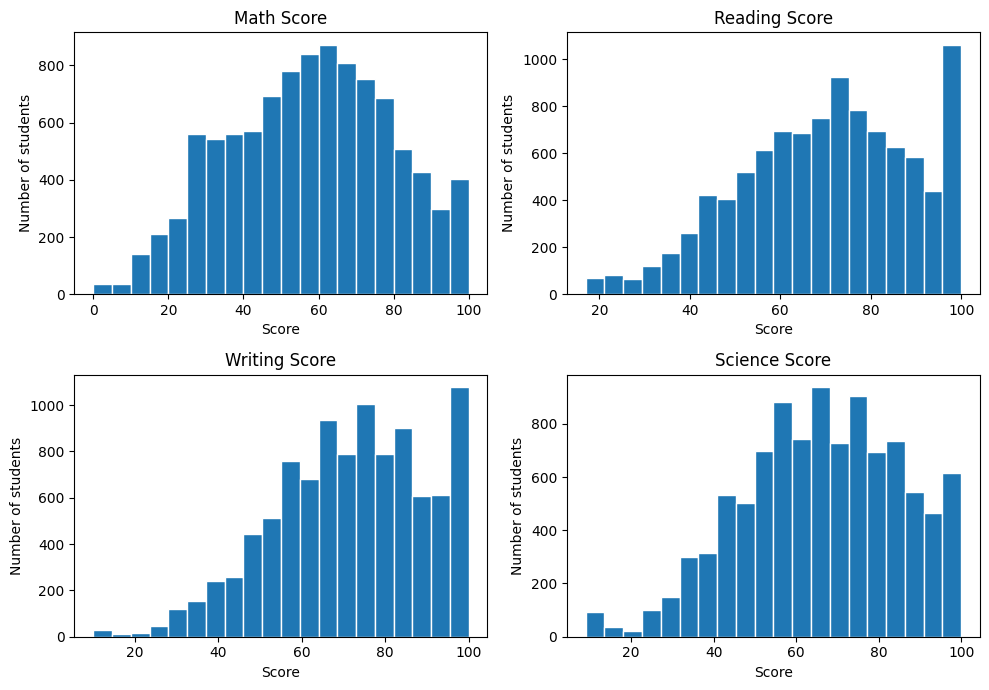

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, col in zip(axes.flatten(), SCORE_COLS):
    ax.hist(df_clean[col], bins=20, edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of students")

plt.tight_layout()
plt.show()

**Observation:** the four subjects are not equally difficult for this group. The average
`math_score` is 57.2, well below `science_score` (66.1), `reading_score` (70.1), and
`writing_score` (71.4), so math is clearly the weakest subject and writing the strongest.
Math scores are also spread out more widely across the 0-100 range than the others.

**Grade distribution**

grade
A        904
B       5654
C       2699
D        672
Fail      62
Name: count, dtype: Int64


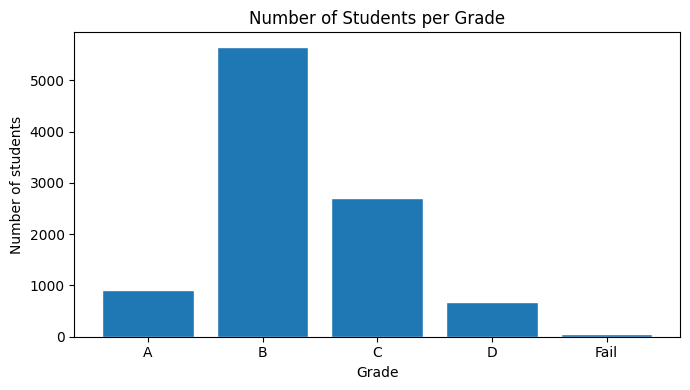

In [16]:
grade_counts = df_clean["grade"].value_counts().reindex(["A", "B", "C", "D", "Fail"])
print(grade_counts)

plt.figure(figsize=(7, 4))
plt.bar(grade_counts.index.astype(str), grade_counts.values, edgecolor="white")
plt.xlabel("Grade")
plt.ylabel("Number of students")
plt.title("Number of Students per Grade")
plt.tight_layout()
plt.show()

**Observation:** most students land in grade B (5,654 students, 56.6%), followed by C. Only
904 students earned an A and just 62 received a Fail, so the grades cluster around B and C
with only thin tails at either end.

**Average score by student background**

In [17]:
for col in ["gender", "lunch", "test_preparation_course", "parental_level_of_education"]:
    print(df_clean.groupby(col)["average_score"].mean().round(2))
    print()

gender
female    69.22
male      63.15
Name: average_score, dtype: float64

lunch
0    65.38
1    66.64
Name: average_score, dtype: float64

test_preparation_course
0    65.85
1    66.73
Name: average_score, dtype: float64

parental_level_of_education
associate's degree    66.09
bachelor's degree     66.13
high school           66.27
master's degree       64.56
some college          66.33
some high school      66.75
Name: average_score, dtype: float64



**Observation:** the clearest gap is by `gender`: female students average 69.2 compared to
63.2 for male students, a difference of about 6.1 points. The other background columns
barely matter in this data. Students who took the test preparation course average only 0.9
points higher than those who did not, the `lunch` groups differ by about 1.3 points, and the
averages across `parental_level_of_education` all sit within a narrow band of 64.6 to 66.7.

## 6. Attendance Analysis

**Distribution of attendance, with a 75% reference line**

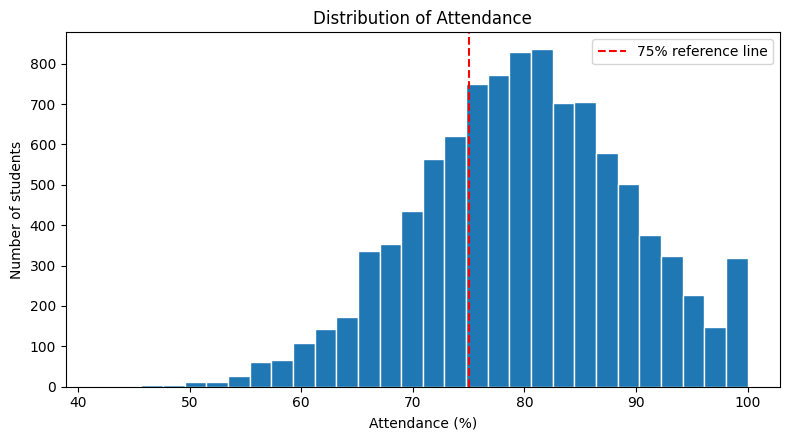

Mean attendance: 79.8%
Median attendance: 79.9%
Students below 75%: 2987 (29.9%)


In [18]:
plt.figure(figsize=(8, 4.5))
plt.hist(df_clean["attendance_percentage"], bins=30, edgecolor="white")
plt.axvline(75, color="red", linestyle="--", label="75% reference line")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of students")
plt.title("Distribution of Attendance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean attendance: {df_clean['attendance_percentage'].mean():.1f}%")
print(f"Median attendance: {df_clean['attendance_percentage'].median():.1f}%")
print(f"Students below 75%: {(df_clean['attendance_percentage'] < 75).sum()} ({(df_clean['attendance_percentage'] < 75).mean() * 100:.1f}%)")

**Average attendance for each grade**

grade
A       85.9
B       81.1
C       77.1
D       73.0
Fail    69.0
Name: attendance_percentage, dtype: float64


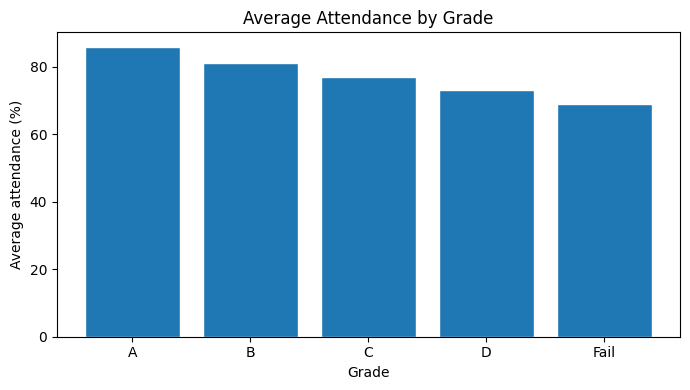

In [19]:
attendance_by_grade = (
    df_clean.groupby("grade")["attendance_percentage"].mean().reindex(["A", "B", "C", "D", "Fail"]).round(1)
)
print(attendance_by_grade)

plt.figure(figsize=(7, 4))
plt.bar(attendance_by_grade.index.astype(str), attendance_by_grade.values, edgecolor="white")
plt.xlabel("Grade")
plt.ylabel("Average attendance (%)")
plt.title("Average Attendance by Grade")
plt.tight_layout()
plt.show()

**Average score for each attendance band**

In [20]:
attendance_band = pd.cut(
    df_clean["attendance_percentage"],
    bins=[0, 60, 70, 80, 90, 100.01],
    labels=["Below 60", "60-69", "70-79", "80-89", "90-100"],
    right=False,
)

band_summary = df_clean.groupby(attendance_band, observed=True).agg(
    students=("roll_no", "count"),
    average_score=("average_score", "mean"),
).round(1)
band_summary

,students,average_score
attendance_percentage,,
Below 60,219,55.9
60-69,1303,60.5
70-79,3483,64.7
80-89,3501,68.1
90-100,1485,71.9


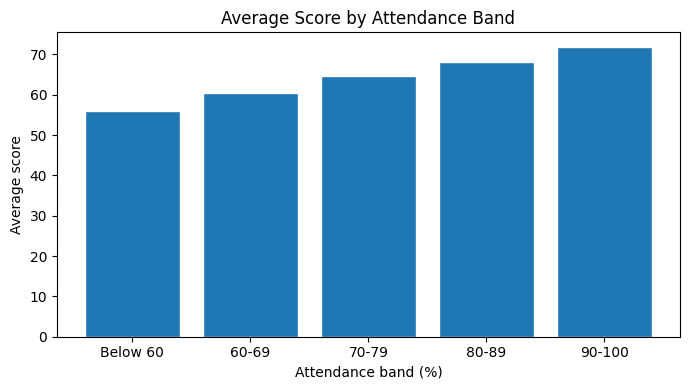

In [21]:
plt.figure(figsize=(7, 4))
plt.bar(band_summary.index.astype(str), band_summary["average_score"], edgecolor="white")
plt.xlabel("Attendance band (%)")
plt.ylabel("Average score")
plt.title("Average Score by Attendance Band")
plt.tight_layout()
plt.show()

**Attendance versus average score, with the correlation**

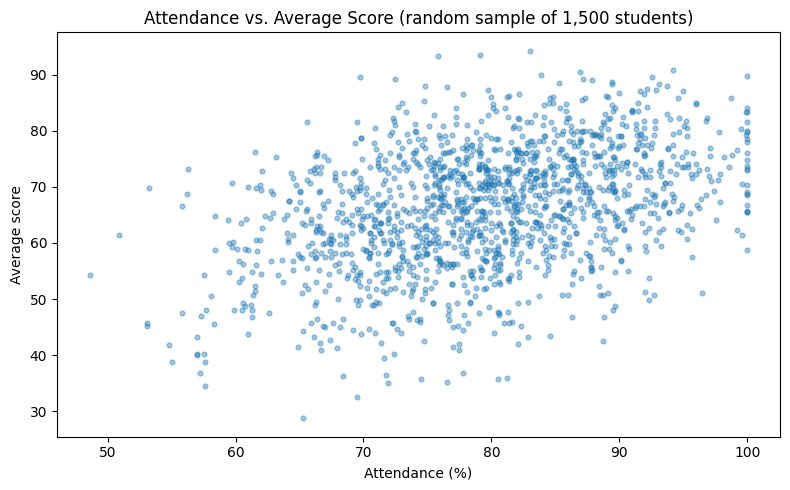

Correlation between attendance and average score: 0.366


In [22]:
sample = df_clean.sample(1500, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample["attendance_percentage"], sample["average_score"], alpha=0.4, s=12)
plt.xlabel("Attendance (%)")
plt.ylabel("Average score")
plt.title("Attendance vs. Average Score (random sample of 1,500 students)")
plt.tight_layout()
plt.show()

correlation = df_clean["attendance_percentage"].corr(df_clean["average_score"])
print(f"Correlation between attendance and average score: {correlation:.3f}")

**Comparing students below and above the 75% line**

In [23]:
low_attendance = df_clean["attendance_percentage"] < 75

df_clean.groupby(low_attendance.map({True: "Below 75%", False: "75% or higher"})).agg(
    students=("roll_no", "count"),
    average_score=("average_score", "mean"),
    average_attendance=("attendance_percentage", "mean"),
).round(1)

,students,average_score,average_attendance
attendance_percentage,,,
75% or higher,7004,68.1,84.6
Below 75%,2987,61.6,68.6


**Observation:** attendance averages 79.8%, and 29.9% of students (2,987) fall below the 75%
line. Average attendance falls steadily with grade, from 85.9% for grade A down to 69.0% for
Fail. The attendance bands tell the same story: students under 60% attendance average 55.9
points, while students at 90% or above average 71.9. The correlation between attendance and
average score is 0.37, a moderate positive relationship with a lot of spread around the
trend (visible in the scatter plot), and students below 75% score about 6.5 points lower on
average than those at 75% or higher. Since the attendance column was simulated with a link
to performance, this result is expected and only shows the analysis workflow, not a real
finding about students.

## 7. Save the Cleaned Dataset

The cleaned data, including the simulated columns, is saved so that Day 32 and Day 33 can
start from it instead of repeating the cleaning.

In [24]:
output_path = "../datasets/Student_Learning_Analytics_Cleaned.csv"
df_clean.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Shape:", df_clean.shape)
print("Columns:", list(df_clean.columns))

Saved: ../datasets/Student_Learning_Analytics_Cleaned.csv
Shape: (9991, 15)
Columns: ['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score', 'total_score', 'grade', 'average_score', 'attendance_percentage', 'study_hours_per_week']


## Outcome

This notebook prepared the student dataset for the Student Performance & Learning Analytics
project, built a data cleaning pipeline, explored the cleaned data, and analyzed attendance.
The raw `Student_Performance_Dataset.csv` file turned out to be intentionally messy, with
213 of its 10,000 rows containing at least one missing value, inconsistent `gender` and
`race_ethnicity` labels, and a text-typed `math_score` column. Instead of dropping every
imperfect row, the pipeline recovered what the data could already tell us (subject scores
from `total_score`, totals from the four scores, grades from the score bands, and a missing
roll number from its pattern) and dropped only 9 rows whose scores could not be rebuilt,
leaving 9,991 students that passed all eight validation checks. The exploration showed that
math is the weakest subject (average 57.2), that grade B is by far the most common, and that
female students average about 6.1 points higher than male students, while test preparation,
lunch type, and parental education made very little difference. Because the dataset had no
attendance or study-time column, both were simulated with a fixed seed, so the attendance
analysis (a correlation of 0.37 with average score, and average scores rising from 55.9 to
71.9 across the attendance bands) demonstrates the workflow rather than a real finding. The
cleaned data was saved as `Student_Learning_Analytics_Cleaned.csv` for the next two days of
the project.